In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Rotten Tomatoes Movies.csv')

In [4]:
print(df.shape)

(16638, 17)


In [5]:
print(df.head())

                                         movie_title  \
0  Percy Jackson & the Olympians: The Lightning T...   
1                                        Please Give   
2                                                 10   
3                    12 Angry Men (Twelve Angry Men)   
4                       20,000 Leagues Under The Sea   

                                          movie_info  \
0  A teenager discovers he's the descendant of a ...   
1  Kate has a lot on her mind. There's the ethics...   
2  Blake Edwards' 10 stars Dudley Moore as George...   
3  A Puerto Rican youth is on trial for murder, a...   
4  This 1954 Disney version of Jules Verne's 20,0...   

                                   critics_consensus rating  \
0  Though it may seem like just another Harry Pot...     PG   
1  Nicole Holofcener's newest might seem slight i...      R   
2                                                NaN      R   
3  Sidney Lumet's feature debut is a superbly wri...     NR   
4  One of D

In [7]:
print(df.dtypes)

movie_title            object
movie_info             object
critics_consensus      object
rating                 object
genre                  object
directors              object
writers                object
cast                   object
in_theaters_date       object
on_streaming_date      object
runtime_in_minutes    float64
studio_name            object
tomatometer_status     object
tomatometer_rating      int64
tomatometer_count       int64
audience_rating       float64
audience_count        float64
dtype: object


In [8]:
print(df.describe())

       runtime_in_minutes  tomatometer_rating  tomatometer_count  \
count        16483.000000        16638.000000       16638.000000   
mean           102.391494           60.466522          56.607104   
std             25.028011           28.587230          66.383800   
min              1.000000            0.000000           5.000000   
25%             90.000000           38.000000          12.000000   
50%             99.000000           66.000000          28.000000   
75%            111.000000           86.000000          76.000000   
max           2000.000000          100.000000         497.000000   

       audience_rating  audience_count  
count     16386.000000    1.638600e+04  
mean         60.470829    1.524797e+05  
std          20.462368    1.817736e+06  
min           0.000000    5.000000e+00  
25%          45.000000    8.642500e+02  
50%          62.000000    4.876500e+03  
75%          77.000000    2.875200e+04  
max         100.000000    3.579764e+07  


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16638 entries, 0 to 16637
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         16638 non-null  object 
 1   movie_info          16614 non-null  object 
 2   critics_consensus   8309 non-null   object 
 3   rating              16638 non-null  object 
 4   genre               16621 non-null  object 
 5   directors           16524 non-null  object 
 6   writers             15289 non-null  object 
 7   cast                16354 non-null  object 
 8   in_theaters_date    15823 non-null  object 
 9   on_streaming_date   16636 non-null  object 
 10  runtime_in_minutes  16483 non-null  float64
 11  studio_name         16222 non-null  object 
 12  tomatometer_status  16638 non-null  object 
 13  tomatometer_rating  16638 non-null  int64  
 14  tomatometer_count   16638 non-null  int64  
 15  audience_rating     16386 non-null  float64
 16  audi

In [11]:
df.isnull().sum()

,0
movie_title,0
movie_info,24
critics_consensus,8329
rating,0
genre,17
directors,114
writers,1349
cast,284
in_theaters_date,815
on_streaming_date,2


In [12]:
df[df.isnull().any(axis=1)].shape

(9028, 17)

In [13]:
(df.isnull().sum() / len(df) * 100) . round(1)

,0
movie_title,0.0
movie_info,0.1
critics_consensus,50.1
rating,0.0
genre,0.1
directors,0.7
writers,8.1
cast,1.7
in_theaters_date,4.9
on_streaming_date,0.0


In [14]:
df['tomatometer_rating'].value_counts()

,count
tomatometer_rating,
100,910
80,404
50,399
83,360
67,357
...,...
99,42
4,39
3,21


In [15]:
df['rating'].value_counts()

,count
rating,
R,6136
NR,4862
PG-13,2885
PG,2062
G,652
NC17,37
PG-13),3
R),1


In [16]:
df['runtime_in_minutes'].describe()

,runtime_in_minutes
count,16483.000000
mean,102.391494
std,25.028011
min,1.000000
25%,90.000000
50%,99.000000
75%,111.000000
max,2000.000000


In [17]:
df[df['runtime_in_minutes'] > 400]

,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
913,Love on the Run,"In this film, Clark Gable and Franchot Tone pl...",NaN,NR,"Classics, Comedy, Romance",W.S. Van Dyke,"John Lee Mahin, Manuel Seff, Gladys Hurlbut","Joan Crawford, Clark Gable, Franchot Tone, Reg...",1936-11-20,2008-06-17,496.0,Unknown,Fresh,80,5,60.0,273.0
10372,Never Sleep Again: The Elm Street Legacy,Explore the origins of everyone's favorite hid...,NaN,NR,"Documentary, Musical & Performing Arts, Televi...","Andrew Kasch, Daniel Farrands",Thommy Hutson,"Heather Langenkamp, Mark Patton, Jennifer Rubi...",2010-01-01,2014-01-21,480.0,Image Entertainment,Fresh,100,7,95.0,1067.0
13539,Terror Tract,John Ritter stars in this three-part horror an...,NaN,R,"Comedy, Horror, Mystery & Suspense","Lance W. Dreesen, Clint Hutchinson, Clint Hutc...",Clint Hutchison,"John Ritter, Bryan Cranston, Rachel York, Carm...",2000-10-18,2001-01-30,2000.0,USA Home Entertainment,Fresh,60,5,35.0,586.0


In [19]:
df[['tomatometer_rating', 'audience_rating']].corr()

,tomatometer_rating,audience_rating
tomatometer_rating,1.000000,0.660111
audience_rating,0.660111,1.000000


In [20]:
df['rating'] = df['rating']. replace(
    {
        'PG-13)':'PG-13',
        'R)':'R'
    }
)

In [21]:
df['rating'].value_counts()

,count
rating,
R,6137
NR,4862
PG-13,2888
PG,2062
G,652
NC17,37


In [22]:
df['critics_consensus'].fillna('None', inplace=True)

/tmp/ipykernel_15943/2495598123.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['critics_consensus'].fillna('None', inplace=True)


In [24]:
median_aud = df['audience_rating'].median()
df['audience_rating'].fillna(median_aud, inplace=True)

/tmp/ipykernel_15943/1880288722.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['audience_rating'].fillna(median_aud, inplace=True)


In [25]:
df['audience_rating'].describe()

,audience_rating
count,16638.000000
mean,60.493990
std,20.307664
min,0.000000
25%,45.000000
50%,62.000000
75%,77.000000
max,100.000000


In [26]:
df['runtime_in_minutes'].fillna(
    df['runtime_in_minutes'].median(), inplace=True
)

/tmp/ipykernel_15943/1264881842.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['runtime_in_minutes'].fillna(


In [27]:
df['studio_name'].fillna('Independent', inplace=True)

/tmp/ipykernel_15943/2219109987.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['studio_name'].fillna('Independent', inplace=True)


In [28]:
df['in_theaters_date'] = pd.to_datetime(
    df['in_theaters_date'], errors='coerce'
)
df['on_streaming_date'] = pd.to_datetime(
    df['on_streaming_date'], errors='coerce'
)

In [29]:
df['runtime_flag'] = df['runtime_in_minutes'] > 300

In [30]:
df['runtime_clean'] = df['runtime_in_minutes'].clip(upper=300)

In [31]:
df.isnull().sum()

,0
movie_title,0
movie_info,24
critics_consensus,0
rating,0
genre,17
directors,114
writers,1349
cast,284
in_theaters_date,815
on_streaming_date,2


In [32]:
df['release_year']    = df['in_theaters_date'].dt.year
df['release_month']   = df['in_theaters_date'].dt.month_name()
df['release_decade']  = (df['release_year'] // 10 * 10).astype('Int64')

In [33]:
df['days_to_streaming'] = (
    df['on_streaming_date'] - df['in_theaters_date']
).dt.days

print(df['days_to_streaming'].describe())

count    15823.000000
mean      3125.896859
std       5911.827045
min      -8704.000000
25%        103.000000
50%        181.000000
75%       3161.000000
max      33506.000000
Name: days_to_streaming, dtype: float64


In [34]:
df['critic_audience_gap'] = (
    df['tomatometer_rating'] - df['audience_rating']
)

In [35]:
conditions = [
    df['critic_audience_gap'] > 20,
    df['critic_audience_gap'] < -20,
]
choices = ['Critics loved it more', 'Audiences loved it more']
df['gap_category'] = np.select(conditions, choices, default='Generally agreed')

df['gap_category'].value_counts()

,count
gap_category,
Generally agreed,11238
Audiences loved it more,2880
Critics loved it more,2520


In [39]:
genre_analysis = df.groupby('primary_genre').agg(
    avg_critic  = ('tomatometer_rating', 'mean'),
    avg_audience= ('audience_rating',     'mean'),
    movie_count = ('movie_title',         'count')
).query('movie_count >= 50').sort_values('avg_critic', ascending=False).round(1)

In [40]:
status_stats = df.groupby('tomatometer_status').agg(
    avg_critic   = ('tomatometer_rating', 'mean'),
    avg_audience = ('audience_rating',     'mean'),
    count        = ('movie_title',         'count')
).round(1)

In [41]:
studio_perf = (
    df.groupby('studio_name')['tomatometer_rating']
    .agg(['mean', 'count', 'std'])
    .query('count >= 20')
    .sort_values('mean', ascending=False)
    .head(10)
    .round(1)
)

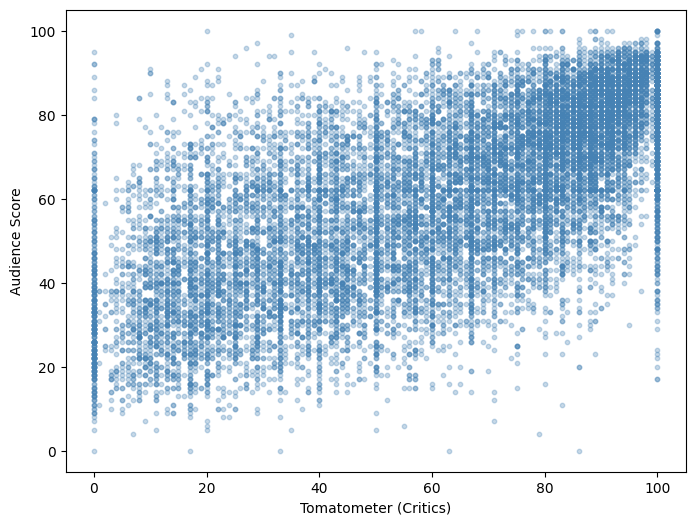

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    df['tomatometer_rating'],
    df['audience_rating'],
    alpha=0.3, s=10, color='steelblue'
)
ax.set_xlabel('Tomatometer (Critics)')
ax.set_ylabel('Audience Score')
plt.show()

<Axes: title={'center': 'Avg Scores by Year'}, xlabel='release_year'>

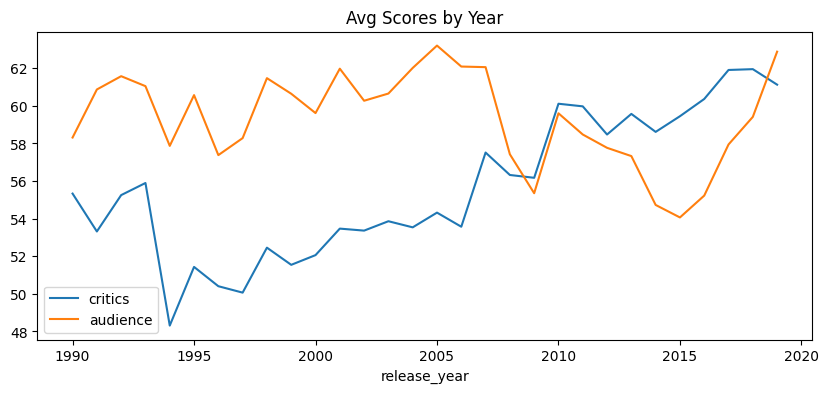

In [43]:
yearly = df.groupby('release_year').agg(
    critics  = ('tomatometer_rating', 'mean'),
    audience = ('audience_rating',     'mean')
).loc[1990:2022]

yearly.plot(figsize=(10,4), title='Avg Scores by Year')

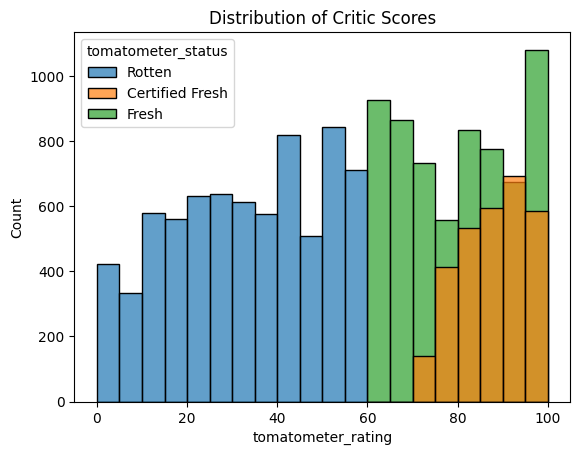

In [44]:
import seaborn as sns

sns.histplot(
    data=df,
    x='tomatometer_rating',
    hue='tomatometer_status',
    bins=20, alpha=0.7
)
plt.title('Distribution of Critic Scores')
plt.show()